# Financial Data Analysis

I will conduct data cleaning and analysis on a dataset of a fictional company's Sales. 

My first notebook on Kaggle used R, so I decided to gather experience with Python! Please feel free to leave any comments/criticisms, they will only help me improve.

## Importing Data/Libraries

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib
import matplotlib.pyplot as plt # visualizations

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

    
financials = pd.read_csv('/kaggle/input/financials/Financials.csv')

financials.head()

/kaggle/input/financials/Financials.csv


,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Canada,Carretera,None,"$1,618.50",$3.00,$20.00,"$32,370.00",$-,"$32,370.00","$16,185.00","$16,185.00",01/01/2014,1,January,2014
1,Government,Germany,Carretera,None,"$1,321.00",$3.00,$20.00,"$26,420.00",$-,"$26,420.00","$13,210.00","$13,210.00",01/01/2014,1,January,2014
2,Midmarket,France,Carretera,None,"$2,178.00",$3.00,$15.00,"$32,670.00",$-,"$32,670.00","$21,780.00","$10,890.00",01/06/2014,6,June,2014
3,Midmarket,Germany,Carretera,None,$888.00,$3.00,$15.00,"$13,320.00",$-,"$13,320.00","$8,880.00","$4,440.00",01/06/2014,6,June,2014
4,Midmarket,Mexico,Carretera,None,"$2,470.00",$3.00,$15.00,"$37,050.00",$-,"$37,050.00","$24,700.00","$12,350.00",01/06/2014,6,June,2014


# Data Cleaning

### Before using this data for analysis we need to:

- #### Strip leading and trailing spaces from column names,

In [2]:
print('Before changes: ')
print(financials.columns)

financials.columns = financials.columns.str.strip()

print('After changes: ')
print(financials.columns)

Before changes: 
Index(['Segment', 'Country', ' Product ', ' Discount Band ', ' Units Sold ',
       ' Manufacturing Price ', ' Sale Price ', ' Gross Sales ', ' Discounts ',
       '  Sales ', ' COGS ', ' Profit ', 'Date', 'Month Number',
       ' Month Name ', 'Year'],
      dtype='object')
After changes: 
Index(['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold',
       'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts',
       'Sales', 'COGS', 'Profit', 'Date', 'Month Number', 'Month Name',
       'Year'],
      dtype='object')


- #### replace middle whitespace with underscores,

In [3]:
# -- replace middle whitespace in column names with underscore

print('Before changes: ')
print(financials.columns)

financials = financials.rename(columns=lambda x: x.replace(' ','_'))

print('After changes: ')
print(financials.columns)

Before changes: 
Index(['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold',
       'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts',
       'Sales', 'COGS', 'Profit', 'Date', 'Month Number', 'Month Name',
       'Year'],
      dtype='object')
After changes: 
Index(['Segment', 'Country', 'Product', 'Discount_Band', 'Units_Sold',
       'Manufacturing_Price', 'Sale_Price', 'Gross_Sales', 'Discounts',
       'Sales', 'COGS', 'Profit', 'Date', 'Month_Number', 'Month_Name',
       'Year'],
      dtype='object')


- #### Get rid of parentheses, money signs, commas, dashes, and spaces in necessary columns,

In [4]:
# Get rid of parentheses, '$', commas, dashes, and spaces in numerical columns
def convert_negatives(val):
    if isinstance(val, str):
        if val.startswith('(') and val.endswith(')'):
            return -float(val[1:-1].replace(',',''))
        else:
            return float(val)
    else:
        return val

columns_to_clean = ['Units_Sold', 'Manufacturing_Price','Sale_Price',
                    'Gross_Sales','Discounts','Sales','COGS','Profit']
for col in columns_to_clean:
    if financials[col].dtype == 'object':
        financials[col] = financials[col].str.replace('$','').str.replace('-','').str.replace(',','').str.strip()
        financials[col] = financials[col].replace('', np.nan).apply(convert_negatives).astype(float)

financials['Product'] = financials['Product'].str.replace(' ','')

- #### and change the Date column to the "datetime" data type

In [5]:
# -- changing date column to date data type

financials['Date'] = pd.to_datetime(financials['Date'], format='mixed',dayfirst=True)

# Visualizations

#### What should this company be focusing on and why?

My analysis focused on drilling into the Segment and Product data of this company to learn:
* The general landscape of the company
* The least profitable Product/Segment
* The most profitable Product/Segment
* and what the historical data between the least and most profitable looks like
    * Find possible trends

## Drilling into Segment data

<Axes: title={'center': 'Segments (using sum of Sales)'}>

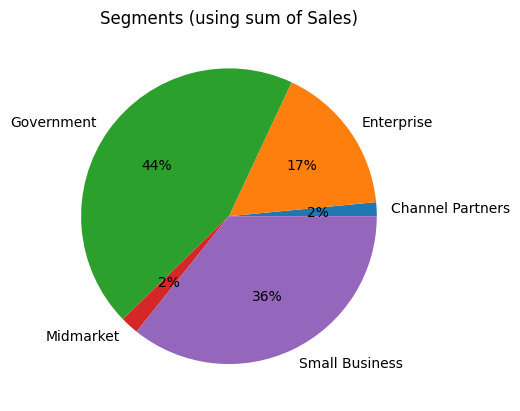

In [6]:
# Pie chart for segments
financials.groupby('Segment').Sales.sum().plot(kind = 'pie',title='Segments (using sum of Sales)', y='Sales', ylabel = '', autopct='%1.0f%%')

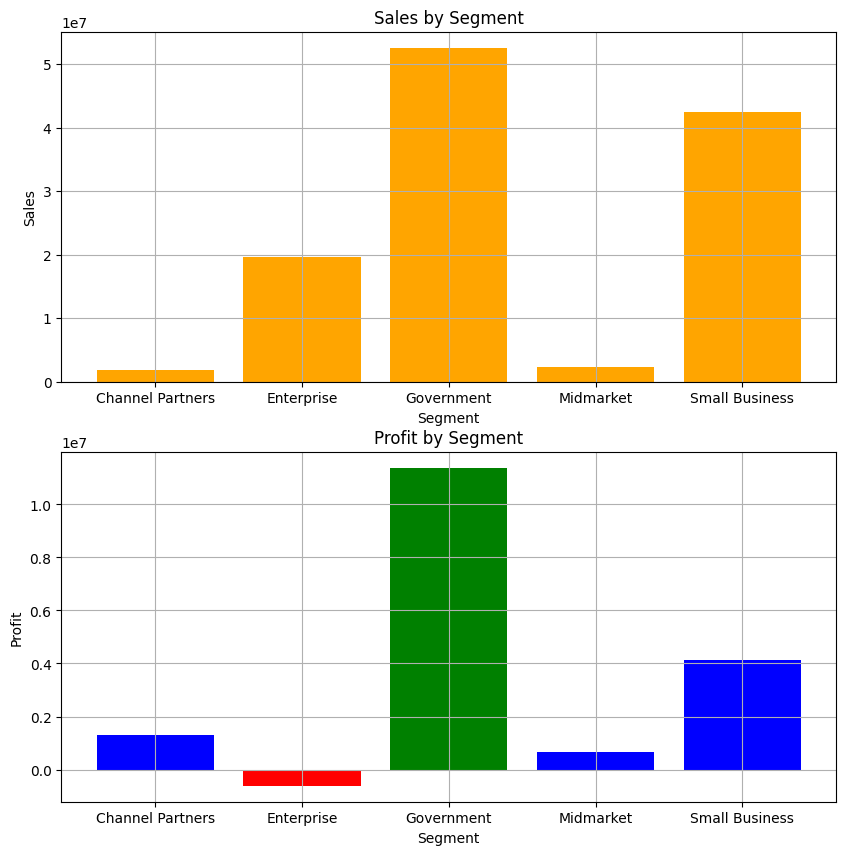

In [7]:
# Bar Chart for Best + Worst Performing Segments

# -- Group data
segments = financials.groupby('Segment').agg({'Sales': 'sum', 'Profit': 'sum'})

# -- Bar Chart : Sum of Sales/Profit per Segment
fig, ax = plt.subplots(2,1,figsize = (10,10))
ax[0].bar(segments.index, segments['Sales'], color = 'orange')
ax[0].set_title('Sales by Segment')
ax[0].set_xlabel('Segment')
ax[0].set_ylabel('Sales')
ax[0].grid()

ax[1].bar(segments.index, segments['Profit'], color = list('brgbb'))
ax[1].set_title('Profit by Segment')
ax[1].set_xlabel('Segment')
ax[1].set_ylabel('Profit')
ax[1].grid()

plt.show()

#### The Enterprise segment is clearly the worst, while the Government segment is the most profitable.
* This is quite interesting, because the Channel Partners and Midmarket segments take up small portions of the company,
* While Enterprise takes up more than the two of them combined.

#### The Enterprise segment does not seem to be worth the resources it is using.
* However, this would require more research and data to act upon.

### Observing the best and worst segments' time-series data may reveal trends:

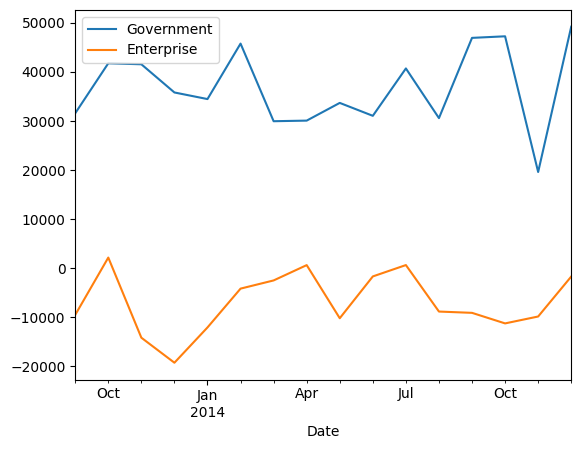

In [8]:
# Line chart for best + worst segments over time
government = financials.loc[financials.Segment == 'Government']
enterprise = financials.loc[financials.Segment == 'Enterprise']

government.groupby('Date').Profit.mean().plot(kind='line',y='Profit',legend=True)
enterprise.groupby('Date').Profit.mean().plot(kind='line',y='Profit',legend=True)

plt.legend(['Government','Enterprise'])
plt.show()

#### The Enterprise segment remains at or below zero profit for the entire year.
* In December, there is also a large dip in profits, which could be explored.
* The segment underperforms overall, and is not dragged down by large outliers.

## Drilling into Product Data

<Axes: title={'center': 'Products (using Sum of Sales)'}>

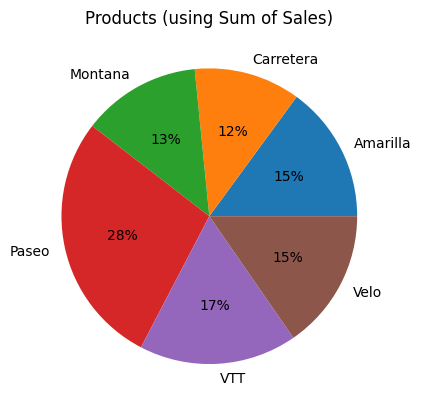

In [9]:
# Pie chart for products
financials.groupby('Product').Sales.sum().plot(kind='pie', y='Sales',ylabel='', title='Products (using Sum of Sales)', autopct='%1.0f%%')

#### The Product landscape is much more balanced, with Paseo holding the largest share.

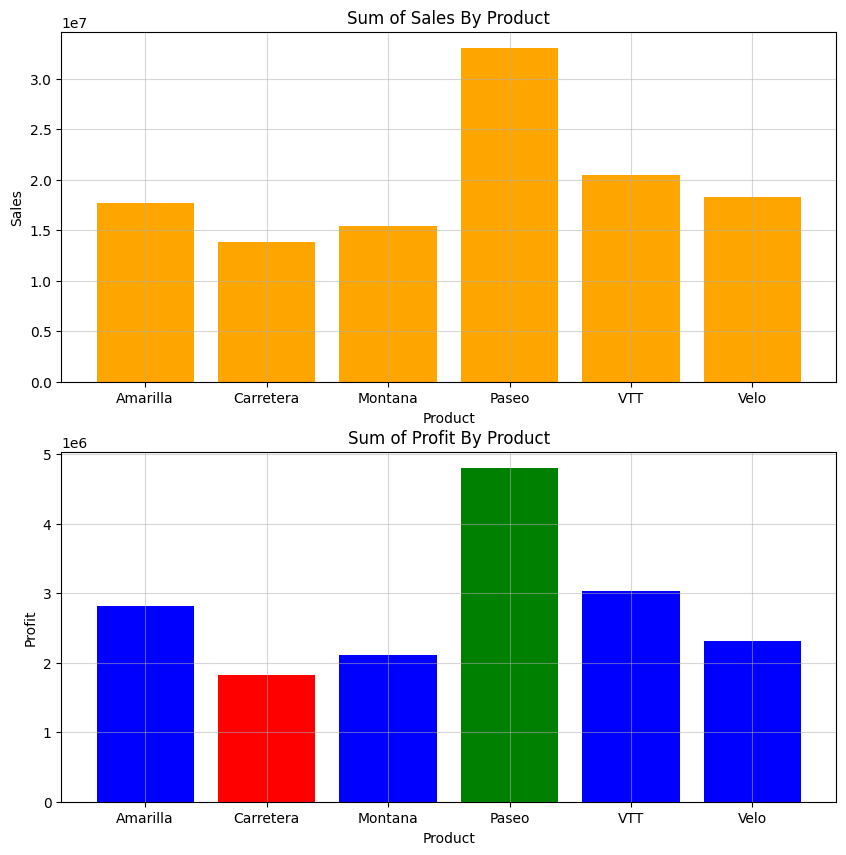

In [10]:
# -- find best and worst performing products
product = financials.groupby('Product').agg({'Sales': 'sum','Profit':'sum'})

fig,ax = plt.subplots(2,1,figsize=(10,10))

ax[0].bar(product.index, product['Sales'], color = 'orange')
ax[0].set_title('Sum of Sales By Product')
ax[0].set_xlabel('Product')
ax[0].set_ylabel('Sales')
ax[0].grid(alpha = 0.5)

ax[1].bar(product.index, product['Profit'], color = list('brbgbb'))
ax[1].set_title('Sum of Profit By Product')
ax[1].set_xlabel('Product')
ax[1].set_ylabel('Profit')
ax[1].grid(alpha = 0.5)


plt.show()

#### Paseo performs the best, while Carretera is the least profitable.
* These trends could be due to their overall size within the company.

#### Let's explore time series data for these as well.

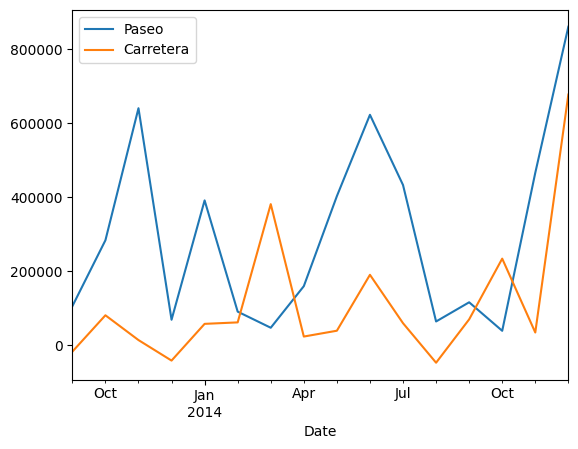

In [11]:
# Make line chart of best + worst products over time

# fig,ax = plt.subplots(2,1,figsize=(8,6), layout='constrained')
paseo_data = financials.loc[financials.Product == 'Paseo']
carretera_data = financials.loc[financials.Product == 'Carretera']

paseo_data.groupby('Date').Profit.sum().plot(kind='line', y='Profit',legend=True)
carretera_data.groupby('Date').Profit.sum().plot(kind='line',y='Profit',legend=True)

plt.legend(['Paseo','Carretera'])
plt.show()

#### Paseo:
* Generally outperforms Carretera
* does not reach negative profit

#### Carretera: 
* Generally follows similar patterns to Paseo
* does reach negative profit
* Performs much better at end of charted time

#### Carretera's performance could be the result of several things:
* Release of a new product, which could cause low beginning profits until growth occurs
    * would explain end-of-year increase in performance
* Poor performance due to low popularity
* Poor performance due to lower overall sales than Paseo

### Finally, let's look at the distribution of product transactions in each segment through a cross-tabulation.

<Axes: xlabel='Segment', ylabel='Product'>

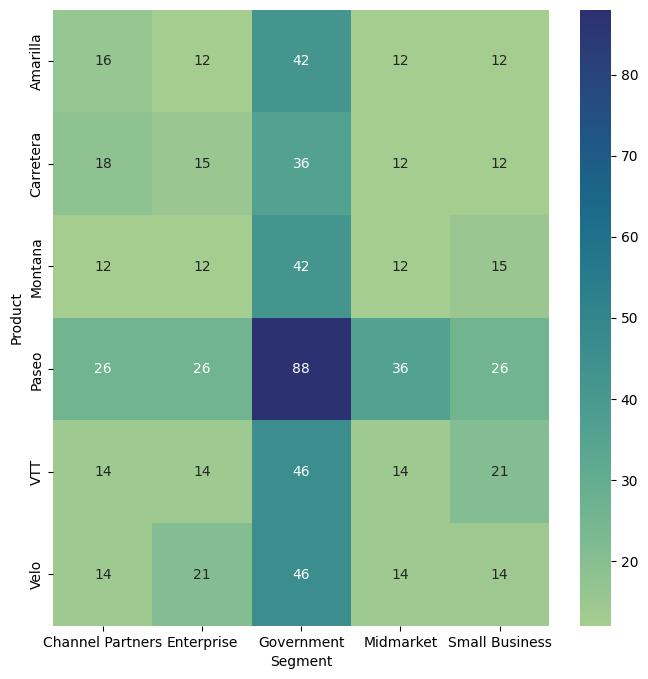

In [12]:
import seaborn as sns

product_segment_crosstab = pd.crosstab(financials['Product'],financials['Segment'])
plt.figure(figsize=(8,8))
sns.heatmap(product_segment_crosstab,annot=True,cmap='crest')

#### Paseo clearly holds a strong presence throughout the company, while other products like Montana and Amarilla show a lower presence.
* This chart could serve as a basis for more research, or for comparison with the other performance charts.

# Conclusion

* #### Best Performing = Government segment and Paseo
* #### Worst Performing = Enterprise segment and Carretera

### The Enterprise segment is performing especially badly considering the resources it is using, and may require **immediate attention**.


### These insights would require more research and data before taking action, but have established a path of research for the company.

Thank you very much for reading this, please feel free to leave comments/criticism.

Have a great day!

Sincerely,

Carson